# HPGCS Figure Generation Notebook

This notebook generates base-paper style plots (compression comparisons and scaling) and additional novel diagrams from project artifacts.

**Outputs** are saved in `paper/figures/`.

In [14]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Resolve repository root robustly whether notebook is run from repo root or paper/
cwd = Path.cwd().resolve()
if (cwd / 'research_results_2026_03_28.json').exists():
    ROOT = cwd
elif (cwd.parent / 'research_results_2026_03_28.json').exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError('Could not locate repository root from current working directory.')

FIG_DIR = ROOT / 'paper' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('FIG_DIR:', FIG_DIR)

ROOT: /home/kelvin/HPGCS_LoPace
FIG_DIR: /home/kelvin/HPGCS_LoPace/paper/figures


In [15]:
# Canonical artifact paths
paths = {
    'combined_json': ROOT / 'research_results_2026_03_28.json',
    'real_200_json': ROOT / 'research_real_200.json',
    'real_1000_json': ROOT / 'research_real_1000.json',
    'real_2000_json': ROOT / 'research_real_2000.json',
    'real_5000_json': ROOT / 'research_real_5000.json',
    'synthetic_scaling_csv': ROOT / 'research_scaling_2026_03_28.csv',
    'real_scaling_5000_csv': ROOT / 'research_real_scaling_5000_real_eval_results.csv',
}

missing = [k for k, p in paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(f'Missing required artifacts: {missing}')

def load_json(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

combined = load_json(paths['combined_json'])
print('Loaded combined experiments:', len(combined.get('experiments', [])))

Loaded combined experiments: 6


In [16]:
# Extract real-cap summary for base-paper-style chart
def extract_real_summary(real_json_path: Path):
    obj = load_json(real_json_path)
    exp = obj['experiments'][0]
    m = exp['methods']
    return {
        'n_prompts': exp['metadata']['n_prompts'],
        'zstd': m['zstd']['ratio'],
        'brotli': m['brotli']['ratio'],
        'dedup': m['corpus_dedup']['ratio'],
        'adaptive': m['adaptive']['ratio'],
        'zstd_time_s': m['zstd']['time_s'],
        'brotli_time_s': m['brotli']['time_s'],
        'dedup_time_s': m['corpus_dedup']['time_s'],
        'adaptive_time_s': m['adaptive']['time_s'],
    }

real_rows = [
    extract_real_summary(paths['real_200_json']),
    extract_real_summary(paths['real_1000_json']),
    extract_real_summary(paths['real_2000_json']),
    extract_real_summary(paths['real_5000_json']),
]
df_real = pd.DataFrame(real_rows).sort_values('n_prompts').reset_index(drop=True)
df_real

,n_prompts,zstd,brotli,dedup,adaptive,zstd_time_s,brotli_time_s,dedup_time_s,adaptive_time_s
0,200,3.068740,3.846004,1.963588,3.021661,0.118921,1.245237,0.128064,0.016567
1,1000,3.140741,3.898283,2.002915,3.088876,0.617935,6.814651,0.562986,0.064702
2,2000,3.211023,3.997347,2.038444,3.158990,0.890677,9.843179,1.061904,0.127481
3,5000,3.219377,4.000751,2.027152,3.167503,2.329546,24.887285,2.608919,0.335347


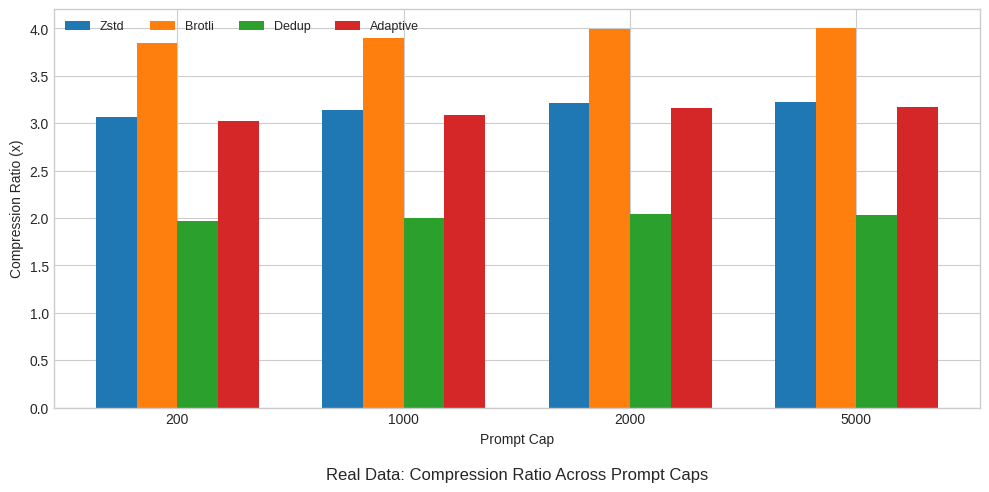

Saved: /home/kelvin/HPGCS_LoPace/paper/figures/fig1_real_caps_ratio.png


In [17]:
# Figure 1: Real-data compression ratio comparison (base-paper style)
methods = ['zstd', 'brotli', 'dedup', 'adaptive']
labels = ['Zstd', 'Brotli', 'Dedup', 'Adaptive']
x = np.arange(len(df_real))
w = 0.18

fig, ax = plt.subplots(figsize=(10, 5))
for i, m in enumerate(methods):
    ax.bar(x + (i - 1.5) * w, df_real[m], width=w, label=labels[i])

ax.set_title('Real Data: Compression Ratio Across Prompt Caps', y=-0.2)
ax.set_xlabel('Prompt Cap')
ax.set_ylabel('Compression Ratio (x)')
ax.set_xticks(x)
ax.set_xticklabels(df_real['n_prompts'].astype(str))
ax.legend(ncol=4, fontsize=9)

out = FIG_DIR / 'fig1_real_caps_ratio.png'
plt.tight_layout()
plt.savefig(out, dpi=300)
plt.show()
print('Saved:', out)

In [18]:
# Extract synthetic scenarios from combined artifact
scenario_keep = {
    'Synthetic: Standard (80% reuse)': 'Standard reuse (80%)',
    'Synthetic: Full reuse (100%)': 'Full reuse (100%)',
    'Synthetic: Low reuse (10%)': 'Low reuse (10%)',
    'Synthetic: Zero reuse (worst case)': 'Zero reuse',
    'Synthetic: Zero reuse + tools/context': 'Zero reuse + tools/context',
}

syn_rows = []
for exp in combined['experiments']:
    name = exp['experiment']
    if name in scenario_keep:
        m = exp['methods']
        syn_rows.append({
            'scenario': scenario_keep[name],
            'zstd': m['zstd']['ratio'],
            'brotli': m['brotli']['ratio'],
            'dedup': m['corpus_dedup']['ratio'],
            'adaptive': m['adaptive']['ratio'],
        })

scenario_order = [
    'Standard reuse (80%)',
    'Full reuse (100%)',
    'Low reuse (10%)',
    'Zero reuse',
    'Zero reuse + tools/context',
]
df_syn = pd.DataFrame(syn_rows)
df_syn['scenario'] = pd.Categorical(df_syn['scenario'], categories=scenario_order, ordered=True)
df_syn = df_syn.sort_values('scenario').reset_index(drop=True)
df_syn

,scenario,zstd,brotli,dedup,adaptive
0,Standard reuse (80%),1.780380,2.466066,5.377364,5.377364
1,Full reuse (100%),1.804615,2.541605,5.956018,5.956018
2,Low reuse (10%),1.720735,2.276558,4.760985,4.760985
3,Zero reuse,1.957719,2.726635,1.530233,2.726635
4,Zero reuse + tools/context,1.895958,2.508443,2.450937,2.508443


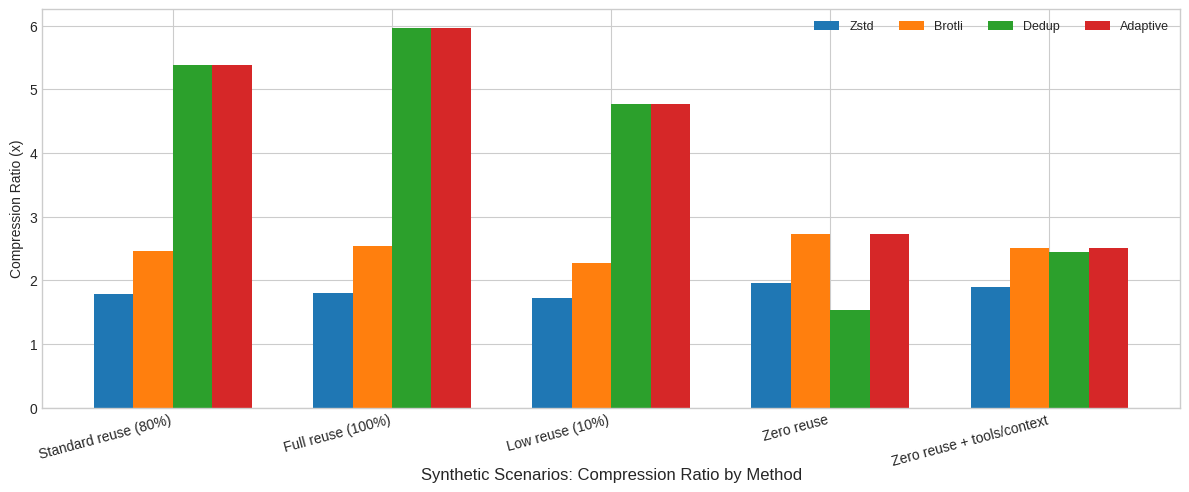

Saved: /home/kelvin/HPGCS_LoPace/paper/figures/fig2_synthetic_scenarios_ratio.png


In [19]:
# Figure 2: Synthetic scenario comparison (base-paper style)
methods = ['zstd', 'brotli', 'dedup', 'adaptive']
labels = ['Zstd', 'Brotli', 'Dedup', 'Adaptive']
x = np.arange(len(df_syn))
w = 0.18

fig, ax = plt.subplots(figsize=(12, 5))
for i, m in enumerate(methods):
    ax.bar(x + (i - 1.5) * w, df_syn[m], width=w, label=labels[i])

ax.set_title('Synthetic Scenarios: Compression Ratio by Method', y=-0.2)
ax.set_ylabel('Compression Ratio (x)')
ax.set_xticks(x)
ax.set_xticklabels(df_syn['scenario'], rotation=15, ha='right')
ax.legend(ncol=4, fontsize=9)

out = FIG_DIR / 'fig2_synthetic_scenarios_ratio.png'
plt.tight_layout()
plt.savefig(out, dpi=300)
plt.show()
print('Saved:', out)

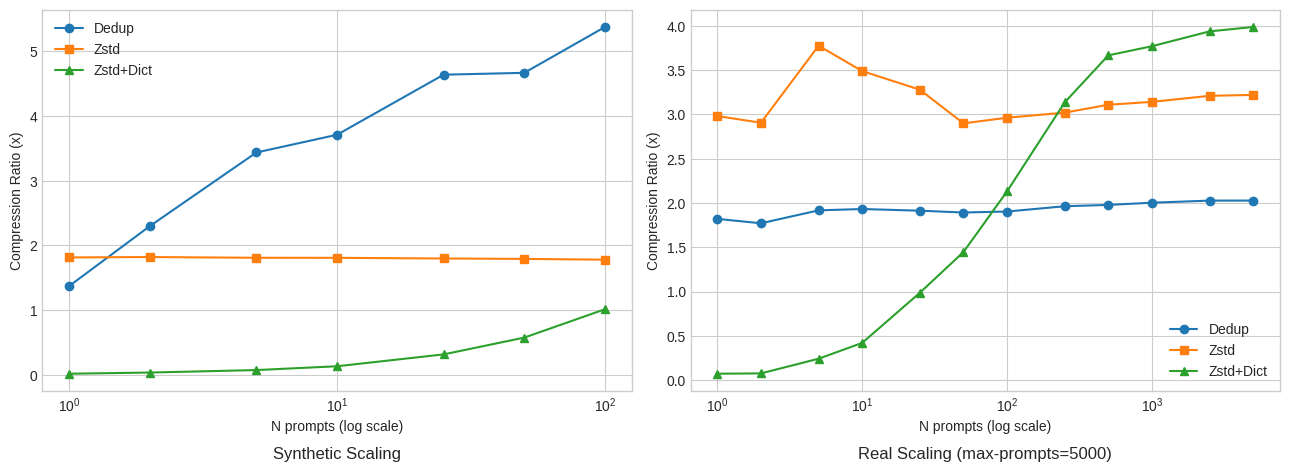

Saved: /home/kelvin/HPGCS_LoPace/paper/figures/fig3_scaling_synthetic_real.png


In [20]:
# Figure 3: Scaling curves (base-paper style)
df_scale_syn = pd.read_csv(paths['synthetic_scaling_csv'])
df_scale_real = pd.read_csv(paths['real_scaling_5000_csv'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=False)

# Synthetic scaling
axes[0].plot(df_scale_syn['n'], df_scale_syn['dedup_ratio'], marker='o', label='Dedup')
axes[0].plot(df_scale_syn['n'], df_scale_syn['zstd_ratio'], marker='s', label='Zstd')
if 'dict_ratio' in df_scale_syn.columns:
    axes[0].plot(df_scale_syn['n'], df_scale_syn['dict_ratio'], marker='^', label='Zstd+Dict')
axes[0].set_xscale('log')
axes[0].set_title('Synthetic Scaling', y=-0.2)
axes[0].set_xlabel('N prompts (log scale)')
axes[0].set_ylabel('Compression Ratio (x)')
axes[0].legend()

# Real scaling
axes[1].plot(df_scale_real['n'], df_scale_real['dedup_ratio'], marker='o', label='Dedup')
axes[1].plot(df_scale_real['n'], df_scale_real['zstd_ratio'], marker='s', label='Zstd')
if 'dict_ratio' in df_scale_real.columns:
    axes[1].plot(df_scale_real['n'], df_scale_real['dict_ratio'], marker='^', label='Zstd+Dict')
axes[1].set_xscale('log')
axes[1].set_title('Real Scaling (max-prompts=5000)', y=-0.2)
axes[1].set_xlabel('N prompts (log scale)')
axes[1].set_ylabel('Compression Ratio (x)')
axes[1].legend()

out = FIG_DIR / 'fig3_scaling_synthetic_real.png'
plt.tight_layout()
plt.savefig(out, dpi=300)
plt.show()
print('Saved:', out)

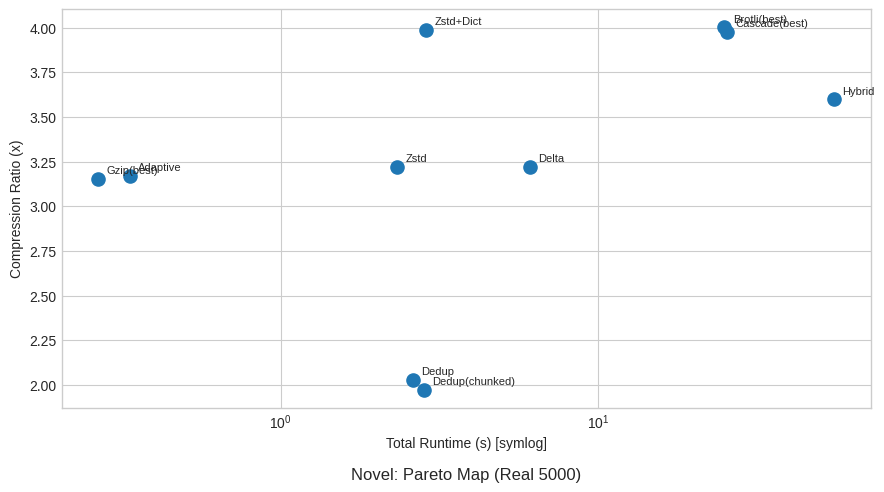

Saved: /home/kelvin/HPGCS_LoPace/paper/figures/novel1_pareto_ratio_vs_time.png


In [21]:
# Novel Figure 1: Pareto frontier (ratio vs total time) on real-5000 run
real5000 = load_json(paths['real_5000_json'])['experiments'][0]['methods']

def get_ratio_time(method_dict, ratio_key='ratio'):
    if method_dict is None:
        return None
    ratio = method_dict.get(ratio_key, method_dict.get('ratio_with_dict', np.nan))
    t = method_dict.get('time_s', np.nan)
    return ratio, t

rows = []
for key, label in [
    ('zstd', 'Zstd'),
    ('gzip', 'Gzip(best)'),
    ('brotli', 'Brotli(best)'),
    ('cascade', 'Cascade(best)'),
    ('hybrid', 'Hybrid'),
    ('zstd_dict', 'Zstd+Dict'),
    ('corpus_dedup', 'Dedup'),
    ('corpus_dedup_chunked', 'Dedup(chunked)'),
    ('delta', 'Delta'),
    ('adaptive', 'Adaptive'),
]:
    if key in real5000:
        r, t = get_ratio_time(real5000[key])
        rows.append({'method': label, 'ratio': r, 'time_s': t})

df_pareto = pd.DataFrame(rows).dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df_pareto['time_s'], df_pareto['ratio'], s=90)
for _, row in df_pareto.iterrows():
    ax.annotate(row['method'], (row['time_s'], row['ratio']), xytext=(6, 4), textcoords='offset points', fontsize=8)
ax.set_xscale('symlog', linthresh=0.01)
ax.set_xlabel('Total Runtime (s) [symlog]')
ax.set_ylabel('Compression Ratio (x)')
ax.set_title('Novel: Pareto Map (Real 5000)', y=-0.2)

out = FIG_DIR / 'novel1_pareto_ratio_vs_time.png'
plt.tight_layout()
plt.savefig(out, dpi=300)
plt.show()
print('Saved:', out)

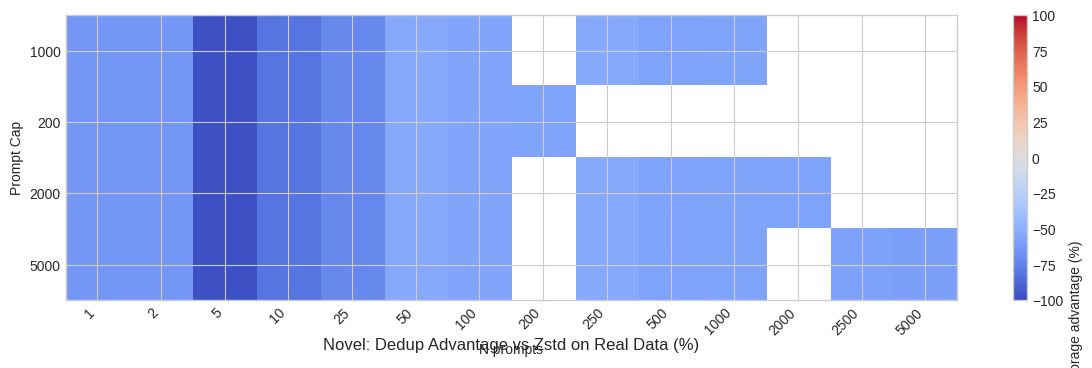

Saved: /home/kelvin/HPGCS_LoPace/paper/figures/novel2_heatmap_dedup_advantage_real_caps.png


In [22]:
# Novel Figure 2: Heatmap of dedup advantage over zstd across real caps
cap_files = [
    ROOT / 'research_real_scaling_200_real_eval_results.csv',
    ROOT / 'research_real_scaling_1000_real_eval_results.csv',
    ROOT / 'research_real_scaling_2000_real_eval_results.csv',
    ROOT / 'research_real_scaling_5000_real_eval_results.csv',
]
cap_labels = ['200', '1000', '2000', '5000']

rows = []
for cap, path in zip(cap_labels, cap_files):
    df = pd.read_csv(path)
    tmp = df[['n', 'dedup_stored', 'zstd_stored']].copy()
    tmp['cap'] = cap
    tmp['adv_pct'] = (1 - tmp['dedup_stored'] / tmp['zstd_stored']) * 100
    rows.append(tmp[['cap', 'n', 'adv_pct']])

df_adv = pd.concat(rows, ignore_index=True)
pivot = df_adv.pivot(index='cap', columns='n', values='adv_pct').sort_index()

fig, ax = plt.subplots(figsize=(12, 3.8))
im = ax.imshow(pivot.values, aspect='auto', cmap='coolwarm', vmin=-100, vmax=100)
ax.set_title('Novel: Dedup Advantage vs Zstd on Real Data (%)', y=-0.2)
ax.set_xlabel('N prompts')
ax.set_ylabel('Prompt Cap')
ax.set_xticks(np.arange(pivot.shape[1]))
ax.set_xticklabels([str(c) for c in pivot.columns], rotation=45, ha='right')
ax.set_yticks(np.arange(pivot.shape[0]))
ax.set_yticklabels([str(i) for i in pivot.index])
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Dedup vs Zstd storage advantage (%)', y=-0.2)

out = FIG_DIR / 'novel2_heatmap_dedup_advantage_real_caps.png'
plt.tight_layout()
plt.savefig(out, dpi=300)
plt.show()
print('Saved:', out)

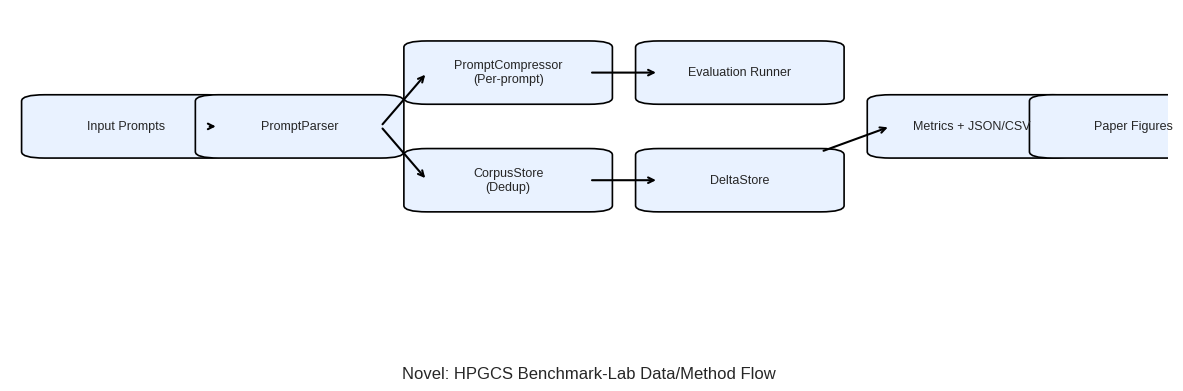

Saved: /home/kelvin/HPGCS_LoPace/paper/figures/novel3_architecture_flow_diagram.png


In [23]:
# Novel Figure 3: Architecture-style flow diagram (static)
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

boxes = [
    ('Input Prompts', (0.03, 0.55)),
    ('PromptParser', (0.18, 0.55)),
    ('PromptCompressor\n(Per-prompt)', (0.36, 0.72)),
    ('CorpusStore\n(Dedup)', (0.36, 0.38)),
    ('DeltaStore', (0.56, 0.38)),
    ('Evaluation Runner', (0.56, 0.72)),
    ('Metrics + JSON/CSV', (0.76, 0.55)),
    ('Paper Figures', (0.90, 0.55)),
]

for label, (x, y) in boxes:
    rect = patches.FancyBboxPatch((x, y), 0.14, 0.16, boxstyle='round,pad=0.02', linewidth=1.2, edgecolor='black', facecolor='#e9f2ff')
    ax.add_patch(rect)
    ax.text(x + 0.07, y + 0.08, label, ha='center', va='center', fontsize=9)

arrows = [
    ((0.17, 0.63), (0.18, 0.63)),
    ((0.32, 0.63), (0.36, 0.80)),
    ((0.32, 0.63), (0.36, 0.46)),
    ((0.50, 0.46), (0.56, 0.46)),
    ((0.50, 0.80), (0.56, 0.80)),
    ((0.70, 0.55), (0.76, 0.63)),
    ((0.90, 0.63), (0.90, 0.63)),
]

for (x1, y1), (x2, y2) in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle='->', lw=1.5))

ax.set_title('Novel: HPGCS Benchmark-Lab Data/Method Flow', y=-0.2, fontsize=12, pad=8)

out = FIG_DIR / 'novel3_architecture_flow_diagram.png'
plt.tight_layout()
plt.savefig(out, dpi=300)
plt.show()
print('Saved:', out)

Saved: /home/kelvin/HPGCS_LoPace/paper/figures/novel4_sankey_storage_flow.html


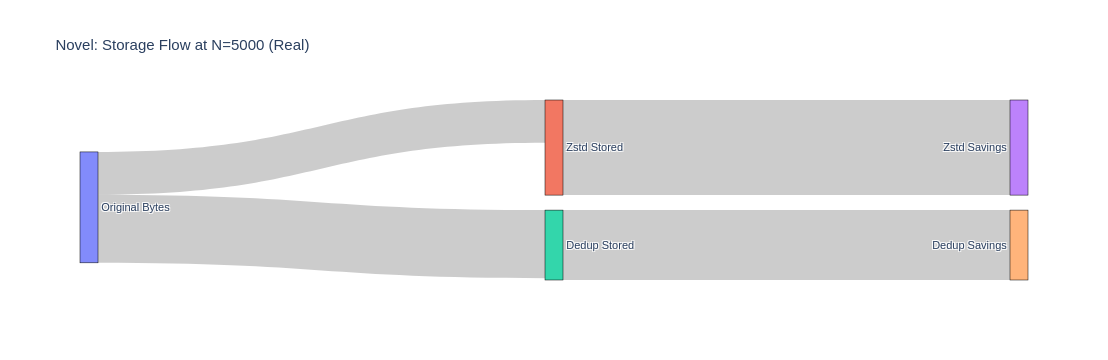

In [24]:
# Optional Novel Figure 4: Sankey storage decomposition (requires plotly)
try:
    import plotly.graph_objects as go

    row = pd.read_csv(paths['real_scaling_5000_csv']).query('n == 5000').iloc[0]
    orig = float(row['orig'])
    dedup = float(row['dedup_stored'])
    zstd = float(row['zstd_stored'])

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=18,
            line=dict(color='black', width=0.5),
            label=['Original Bytes', 'Zstd Stored', 'Dedup Stored', 'Zstd Savings', 'Dedup Savings']
        ),
        link=dict(
            source=[0, 0, 1, 2],
            target=[1, 2, 3, 4],
            value=[zstd, dedup, orig - zstd, orig - dedup]
        )
    )])

    fig.update_layout(title_text='Novel: Storage Flow at N=5000 (Real)', font_size=11)
    out_html = FIG_DIR / 'novel4_sankey_storage_flow.html'
    fig.write_html(out_html)
    print('Saved:', out_html)
    fig.show()
except Exception as e:
    print('Plotly Sankey skipped:', e)

In [25]:
# Auto-generate LaTeX figure blocks for saved images
from textwrap import dedent

img_exts = {'.png', '.jpg', '.jpeg', '.pdf'}
image_files = sorted([p for p in FIG_DIR.iterdir() if p.suffix.lower() in img_exts])

if not image_files:
    print('No image files found in', FIG_DIR)
else:
    print(f'Found {len(image_files)} image files in {FIG_DIR}\n')

for idx, p in enumerate(image_files, start=1):
    rel = p.relative_to(ROOT).as_posix()
    label = f'fig:auto_{p.stem}'
    caption = p.stem.replace('_', ' ').title()
    block = dedent(f'''\
    % Figure {idx}
    \begin{{figure}}[t]
    \centering
    \includegraphics[width=\linewidth]{{{rel}}}
    \caption{{{caption}}}
    \label{{{label}}}
    \end{{figure}}
    ''').strip()
    print(block)
    print('')

Found 6 image files in /home/kelvin/HPGCS_LoPace/paper/figures

% Figure 1
egin{figure}[t]
\centering
\includegraphics[width=\linewidth]{paper/figures/fig1_real_caps_ratio.png}
\caption{Fig1 Real Caps Ratio}
\label{fig:auto_fig1_real_caps_ratio}
\end{figure}

% Figure 2
egin{figure}[t]
\centering
\includegraphics[width=\linewidth]{paper/figures/fig2_synthetic_scenarios_ratio.png}
\caption{Fig2 Synthetic Scenarios Ratio}
\label{fig:auto_fig2_synthetic_scenarios_ratio}
\end{figure}

% Figure 3
egin{figure}[t]
\centering
\includegraphics[width=\linewidth]{paper/figures/fig3_scaling_synthetic_real.png}
\caption{Fig3 Scaling Synthetic Real}
\label{fig:auto_fig3_scaling_synthetic_real}
\end{figure}

% Figure 4
egin{figure}[t]
\centering
\includegraphics[width=\linewidth]{paper/figures/novel1_pareto_ratio_vs_time.png}
\caption{Novel1 Pareto Ratio Vs Time}
\label{fig:auto_novel1_pareto_ratio_vs_time}
\end{figure}

% Figure 5
egin{figure}[t]
\centering
\includegraphics[width=\linewidth]{paper/f

In [26]:
# Write all generated LaTeX figure blocks to a reusable include file
from textwrap import dedent

img_exts = {'.png', '.jpg', '.jpeg', '.pdf'}
image_files = sorted([p for p in FIG_DIR.iterdir() if p.suffix.lower() in img_exts])

if not image_files:
    print('No image files found in', FIG_DIR)
else:
    tex_lines = [
        '% Auto-generated by HPGCS_graphs_and_diagrams.ipynb',
        '% Include in paper with: \input{paper/figures_auto.tex}',
        ''
    ]

    for idx, p in enumerate(image_files, start=1):
        rel = p.relative_to(ROOT).as_posix()
        label = f'fig:auto_{p.stem}'
        caption = p.stem.replace('_', ' ').title()
        block = dedent(f'''\
        % Figure {idx}
        \begin{{figure}}[t]
        \centering
        \includegraphics[width=\linewidth]{{{rel}}}
        \caption{{{caption}}}
        \label{{{label}}}
        \end{{figure}}
        ''').strip()
        tex_lines.extend([block, ''])

    out_tex = ROOT / 'paper' / 'figures_auto.tex'
    out_tex.write_text('\n'.join(tex_lines), encoding='utf-8')
    print('Wrote:', out_tex)
    print('Use in LaTeX: \input{paper/figures_auto.tex}')

Wrote: /home/kelvin/HPGCS_LoPace/paper/figures_auto.tex
Use in LaTeX: \input{paper/figures_auto.tex}


## Generated Files

Expected key outputs:
- `fig1_real_caps_ratio.png`
- `fig2_synthetic_scenarios_ratio.png`
- `fig3_scaling_synthetic_real.png`
- `novel1_pareto_ratio_vs_time.png`
- `novel2_heatmap_dedup_advantage_real_caps.png`
- `novel3_architecture_flow_diagram.png`
- `novel4_sankey_storage_flow.html` (optional, if plotly is available)